In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix project.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


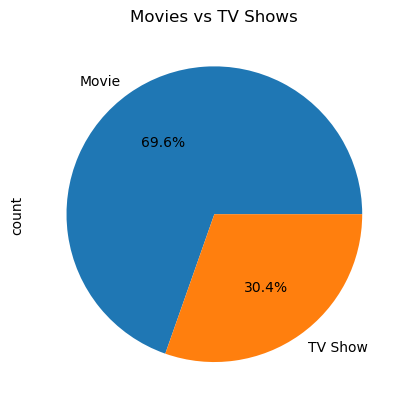

In [3]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Movies vs TV Shows")
plt.show()

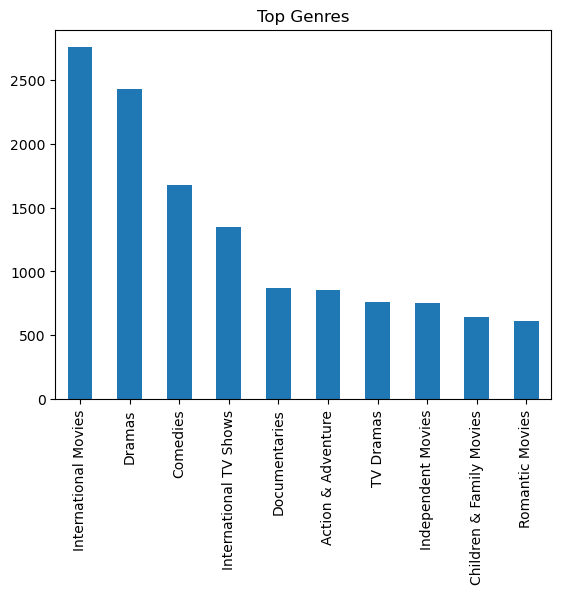

In [4]:
genres = df['listed_in'].str.split(', ', expand=True).stack()
genres.value_counts().head(10).plot(kind='bar')
plt.title("Top Genres")
plt.show()

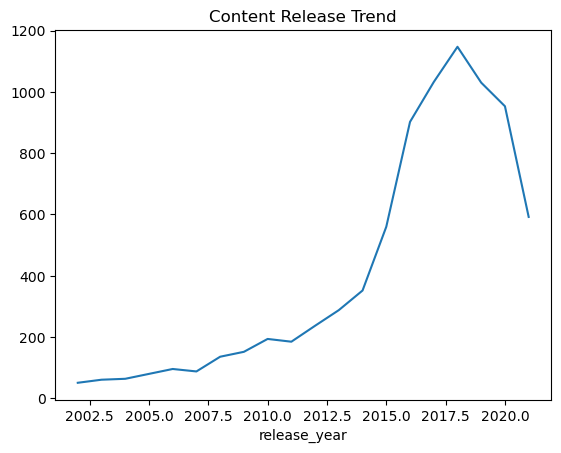

In [6]:
df['release_year'].value_counts().sort_index().tail(20).plot()
plt.title("Content Release Trend")
plt.show()

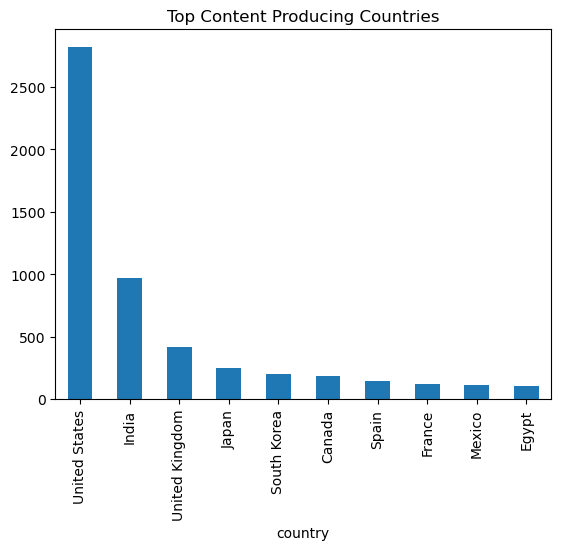

In [7]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top Content Producing Countries")
plt.show()

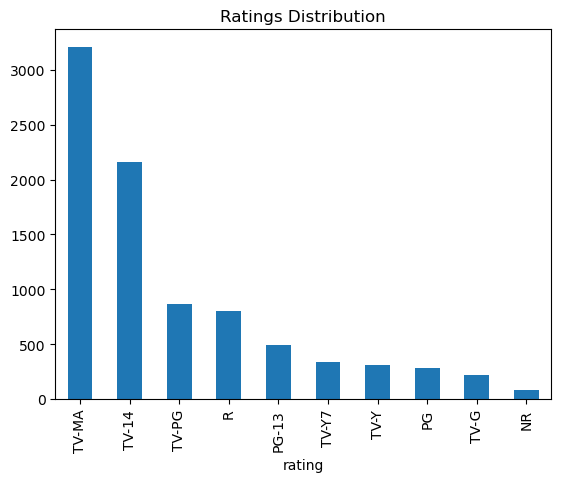

In [9]:
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title("Ratings Distribution")
plt.show()

In [10]:
pd.crosstab(df['type'], df['listed_in']).head()

listed_in,Action & Adventure,"Action & Adventure, Anime Features","Action & Adventure, Anime Features, Children & Family Movies","Action & Adventure, Anime Features, Classic Movies","Action & Adventure, Anime Features, Horror Movies","Action & Adventure, Anime Features, International Movies","Action & Adventure, Anime Features, Sci-Fi & Fantasy","Action & Adventure, Children & Family Movies","Action & Adventure, Children & Family Movies, Classic Movies","Action & Adventure, Children & Family Movies, Comedies",...,"TV Dramas, TV Sci-Fi & Fantasy, Teen TV Shows","TV Dramas, TV Thrillers","TV Dramas, Teen TV Shows","TV Horror, TV Mysteries, TV Sci-Fi & Fantasy","TV Horror, TV Mysteries, TV Thrillers","TV Horror, TV Mysteries, Teen TV Shows","TV Horror, Teen TV Shows","TV Sci-Fi & Fantasy, TV Thrillers",TV Shows,Thrillers
type,,,,,,,,,,,,,,,,,,,,,
Movie,128,1,4,2,1,38,4,2,4,5,...,0,0,0,0,0,0,0,0,0,65
TV Show,0,0,0,0,0,0,0,0,0,0,...,1,5,6,4,4,1,2,1,16,0


In [11]:
df['director'].value_counts().head(10)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

In [12]:
actors = df['cast'].str.split(', ', expand=True).stack()
actors.value_counts().head(10)

Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Paresh Rawal        28
Name: count, dtype: int64

In [13]:
movies = df[df['type']=='Movie']
movies['duration'] = movies['duration'].str.replace(' min','').astype(float)

movies['duration'].mean()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_25904\1308558026.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration'] = movies['duration'].str.replace(' min','').astype(float)


np.float64(99.57718668407311)

In [14]:
shows = df[df['type']=='TV Show']
shows['duration'].value_counts().head()

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
4 Seasons      95
5 Seasons      65
Name: count, dtype: int64

In [16]:
df['director'].value_counts().head(10)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

In [17]:
actors = df['cast'].str.split(', ', expand=True).stack()
actors.value_counts().head(10)

Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Paresh Rawal        28
Name: count, dtype: int64

In [18]:
df['genre'] = df['listed_in'].str.split(', ', expand=True)[0]

df.groupby(['director', 'genre']).size().sort_values(ascending=False).head(10)

director                genre                   
Rajiv Chilaka           Children & Family Movies    19
Raúl Campos, Jan Suter  Stand-Up Comedy             18
Suhas Kadav             Children & Family Movies    16
Marcus Raboy            Stand-Up Comedy             15
Jay Karas               Stand-Up Comedy             13
Jay Chapman             Stand-Up Comedy             11
Don Michael Paul        Action & Adventure           9
Shannon Hartman         Stand-Up Comedy              8
Hakan Algül             Comedies                     8
Youssef Chahine         Classic Movies               7
dtype: int64

In [19]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min', '').astype(float)

print("Average Duration:", movies['duration'].mean())

Average Duration: 99.57718668407311


In [20]:
shows = df[df['type'] == 'TV Show']

shows['duration'].value_counts().head(10)

duration
1 Season      1793
2 Seasons      425
3 Seasons      199
4 Seasons       95
5 Seasons       65
6 Seasons       33
7 Seasons       23
8 Seasons       17
9 Seasons        9
10 Seasons       7
Name: count, dtype: int64

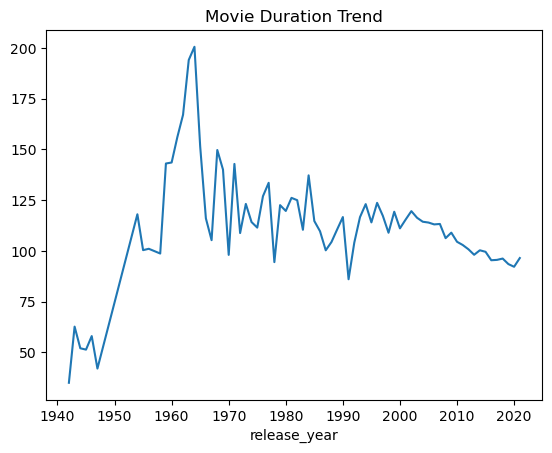

In [21]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min', '').astype(float)

movies.groupby('release_year')['duration'].mean().plot()
plt.title("Movie Duration Trend")
plt.show()

In [23]:
df['genre'] = df['listed_in'].str.split(', ', expand=True)[0]

df.groupby(['release_year', 'genre']).size().unstack().fillna(0).tail(10)

genre,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,Sports Movies,Stand-Up Comedy,Stand-Up Comedy & Talk Shows,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Sci-Fi & Fantasy,TV Shows,Thrillers
release_year,,,,,,,,,,,,,,,,,,,,,
2012,29.0,0.0,4.0,9.0,21.0,0.0,0.0,48.0,3.0,0.0,...,0.0,12.0,0.0,0.0,5.0,1.0,0.0,0.0,0.0,0.0
2013,29.0,1.0,5.0,10.0,34.0,0.0,0.0,47.0,8.0,1.0,...,0.0,9.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
2014,28.0,0.0,11.0,7.0,29.0,0.0,0.0,60.0,9.0,0.0,...,0.0,11.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
2015,53.0,1.0,11.0,22.0,23.0,1.0,0.0,76.0,18.0,0.0,...,0.0,16.0,1.0,1.0,7.0,4.0,3.0,0.0,1.0,3.0
2016,80.0,3.0,11.0,30.0,41.0,1.0,0.0,116.0,31.0,0.0,...,0.0,34.0,1.0,2.0,6.0,3.0,0.0,0.0,0.0,7.0
2017,89.0,4.0,10.0,34.0,52.0,1.0,0.0,133.0,46.0,0.0,...,1.0,57.0,6.0,1.0,9.0,12.0,0.0,1.0,2.0,8.0
2018,81.0,4.0,24.0,37.0,61.0,1.0,1.0,138.0,71.0,1.0,...,0.0,58.0,13.0,5.0,16.0,4.0,1.0,0.0,0.0,8.0
2019,44.0,4.0,18.0,26.0,79.0,3.0,0.0,118.0,83.0,0.0,...,0.0,48.0,4.0,7.0,22.0,15.0,5.0,0.0,2.0,10.0
2020,46.0,1.0,21.0,33.0,80.0,2.0,0.0,90.0,76.0,0.0,...,0.0,41.0,5.0,9.0,25.0,13.0,1.0,0.0,2.0,5.0


In [24]:
df['genre'] = df['listed_in'].str.split(', ', expand=True)[0]

df.groupby(['country', 'genre']).size().sort_values(ascending=False).head(10)

country         genre                   
United States   Documentaries               388
India           Dramas                      384
United States   Dramas                      376
                Comedies                    338
India           Comedies                    262
United States   Children & Family Movies    256
                Action & Adventure          249
                Stand-Up Comedy             209
United Kingdom  British TV Shows            196
United States   Kids' TV                    142
dtype: int64

In [26]:
df['director'] = df['director'].replace('', 'Unknown').fillna('Unknown')
df['cast'] = df['cast'].replace('', 'Unknown').fillna('Unknown')
df['country'] = df['country'].replace('', 'Unknown').fillna('Unknown')

In [27]:
df['director'].isnull().sum()
df['cast'].isnull().sum()
df['country'].isnull().sum()

np.int64(0)

In [34]:
df.to_csv("cleaned_netflix.csv", index=False)